In [1]:
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt

c:\Users\Atharv\OneDrive\文件\urban-heat-islands\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
model = joblib.load(
    "../models/"
    "final_first_xgboost_environmental.pkl"
)

In [4]:
df = pd.read_csv(
    "../../data/processed/"
    "raipur_5year_processed.csv"
)

In [6]:
test_df = df[
    df["Year"] == 2026
].copy()

In [7]:
features = [
    "NDVI",
    "NDBI",
    "NDWI"
]

X_test = test_df[
    features
]

In [8]:
explainer = shap.TreeExplainer(
    model
)

In [9]:
shap_values = explainer(
    X_test
)

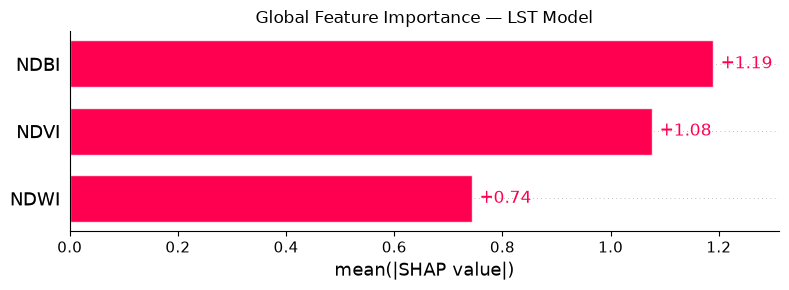

In [10]:
shap.plots.bar(
    shap_values,
    show=False
)

plt.title(
    "Global Feature Importance — LST Model"
)

plt.tight_layout()

plt.show()

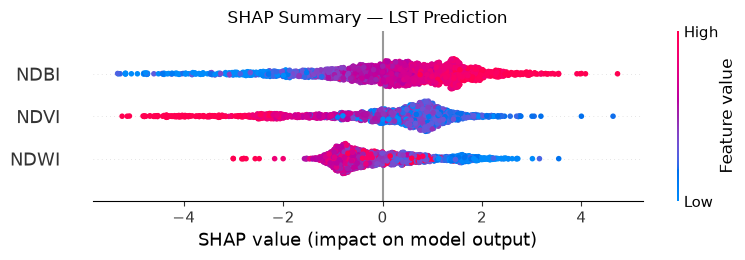

In [11]:
shap.summary_plot(
    shap_values.values,
    X_test,
    show=False
)

plt.title(
    "SHAP Summary — LST Prediction"
)

plt.tight_layout()

plt.show()

In [12]:
sample_index = 0

sample = X_test.iloc[
    [sample_index]
]

sample

,NDVI,NDBI,NDWI
4,0.098629,0.083194,-0.139808


In [13]:
sample_explanation = explainer(
    sample
)

In [14]:
print(
    "Observed LST:",
    test_df.iloc[
        sample_index
    ]["LST"]
)

print(
    "Predicted LST:",
    model.predict(sample)[0]
)

Observed LST: 49.78449275000003
Predicted LST: 50.603085


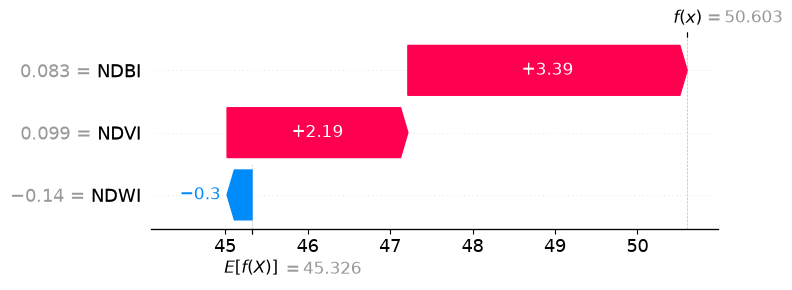

In [15]:
shap.plots.waterfall(
    sample_explanation[0],
    show=False
)

plt.tight_layout()

plt.show()